In [1]:
# Basic usage sketch
from kan import KAN, create_dataset
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
# import scaler
from sklearn.preprocessing import StandardScaler
import sympy
import numpy as np

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[4,2,1,1], grid=3, k=3, seed=1, device='cpu')
f = lambda x: torch.exp((torch.sin(torch.pi*(x[:,[0]]**2+x[:,[1]]**2))+torch.sin(torch.pi*(x[:,[2]]**2+x[:,[3]]**2)))/2)
dataset = create_dataset(f, n_var=4, train_num=3000, device='cpu')

# train the model
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.005, lamb_entropy=2.)


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.69e-01 | test_loss: 1.75e-01 | reg: 9.38e+00 | : 100%|█| 50/50 [00:36<00:00,  1.39it

saving model version 0.1


{'train_loss': [array(0.515963, dtype=float32),
  array(0.40315348, dtype=float32),
  array(0.32434228, dtype=float32),
  array(0.25314593, dtype=float32),
  array(0.23169178, dtype=float32),
  array(0.21901064, dtype=float32),
  array(0.20170732, dtype=float32),
  array(0.19496204, dtype=float32),
  array(0.18542248, dtype=float32),
  array(0.18174925, dtype=float32),
  array(0.18347842, dtype=float32),
  array(0.17917399, dtype=float32),
  array(0.17418908, dtype=float32),
  array(0.17304292, dtype=float32),
  array(0.17287493, dtype=float32),
  array(0.17647712, dtype=float32),
  array(0.17525066, dtype=float32),
  array(0.17223981, dtype=float32),
  array(0.17174684, dtype=float32),
  array(0.17116657, dtype=float32),
  array(0.17402615, dtype=float32),
  array(0.17226158, dtype=float32),
  array(0.17099036, dtype=float32),
  array(0.17091018, dtype=float32),
  array(0.16943887, dtype=float32),
  array(0.17092553, dtype=float32),
  array(0.17096326, dtype=float32),
  array(0.169662

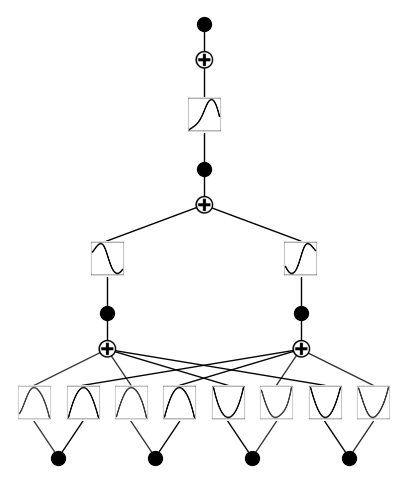

In [2]:
model.plot()

In [3]:
model = model.prune(edge_th=1e-2)

saving model version 0.2


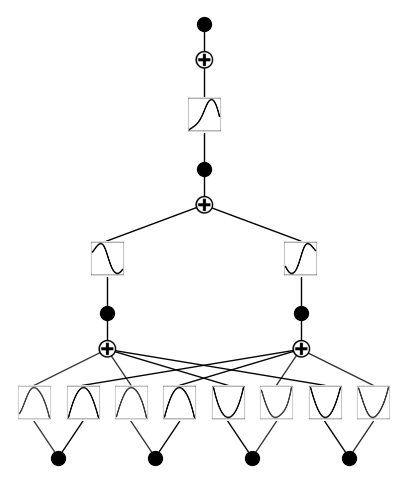

In [4]:
model.plot()

In [5]:
model.auto_symbolic()

fixing (0,0,0) with cos, r2=0.9961079955101013, c=2
fixing (0,0,1) with x^2, r2=0.9998387694358826, c=2
fixing (0,1,0) with x^2, r2=0.9993931651115417, c=2
fixing (0,1,1) with x^2, r2=0.9997091293334961, c=2
fixing (0,2,0) with x^2, r2=0.998766303062439, c=2
fixing (0,2,1) with 0, r2=0.0, c=0
fixing (0,3,0) with cos, r2=0.9997519850730896, c=2
fixing (0,3,1) with cos, r2=0.9976325631141663, c=2
fixing (1,0,0) with 0, r2=0.0, c=0
fixing (1,1,0) with 0, r2=0.0, c=0
fixing (2,0,0) with 0, r2=0.0, c=0
saving model version 0.3


In [6]:
model.symbolic_formula()[0]

[1.57402110099792]